AydinDemir.com | created: Mar 08, 2026 | modified: Mar 08, 2026

---

## Create Response Spectra of EQ Ground Motion Data

### 1. Read and Plot AFAD Processed Acceleration Records

Time step dt = 0.01 sec
Duration = 77.0 sec
Number of points = 7701


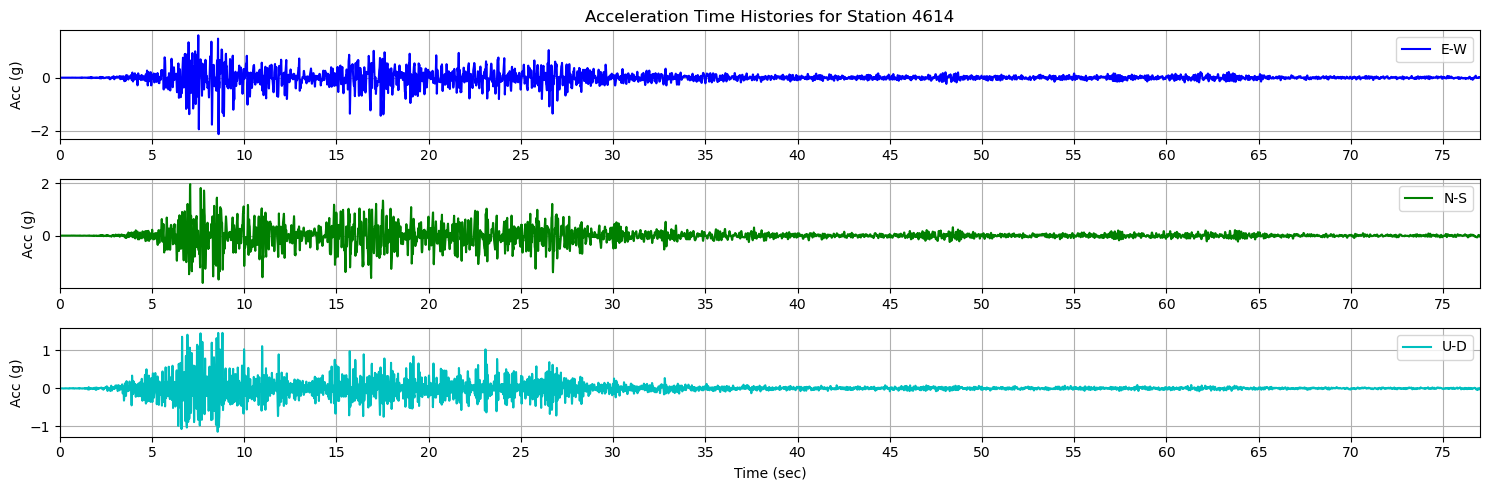

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import os

# define record parameters
st_id = 4614   # Station ID
HeaderNo = 1   # only the header line "# t(sec) acc(g)"

# define file path
file_path_E = "EQ_Record_Files/20230206011732_4614_processed_Acc_E.txt"  # E-W component
file_path_N = "EQ_Record_Files/20230206011732_4614_processed_Acc_N.txt"  # N-S component
file_path_U = "EQ_Record_Files/20230206011732_4614_processed_Acc_U.txt"  # U-D component

# read the record file (two columns: time, acceleration)
t, acc_E = np.loadtxt(file_path_E, skiprows=HeaderNo, unpack=True)
t, acc_N = np.loadtxt(file_path_N, skiprows=HeaderNo, unpack=True)
t, acc_U = np.loadtxt(file_path_U, skiprows=HeaderNo, unpack=True)

# compute dt automatically
dt = t[1] - t[0]

# record properties
dur = t[-1]

print(f"Time step dt = {dt} sec")
print(f"Duration = {dur} sec")
print(f"Number of points = {len(acc_E)}")


# Plot Ground Motions
fig, xy = plt.subplots(nrows = 3, ncols = 1, figsize = (15, 5)) # Alt alta çizim
xy[0].plot(t, acc_E, color = 'b', label = 'E-W')
xy[0].set(ylabel = 'Acc (g)', title = f'Acceleration Time Histories for Station {st_id}')
xy[0].set_xlim(0, dur)
xy[0].set_xticks(np.arange(0, dur + 1, 5)) 
xy[0].legend()
xy[0].grid()
xy[1].plot(t, acc_N, color = 'g', label = 'N-S')
xy[1].set(ylabel = 'Acc (g)')
xy[1].set_xlim(0, dur)
xy[1].set_xticks(np.arange(0, dur + 1, 5)) 
xy[1].legend()
xy[1].grid()
xy[2].plot(t, acc_U, color = 'c', label = 'U-D')
xy[2].set(xlabel = 'Time (sec)', ylabel = 'Acc (g)')
xy[2].set_xlim(0, dur) 
xy[2].set_xticks(np.arange(0, dur + 1, 5)) 
xy[2].legend() 
xy[2].grid()
fig.tight_layout()
plt.show()

### 2. Response Spectrum Calculation
Damping ratio: 5%

Response spectrum calculated.


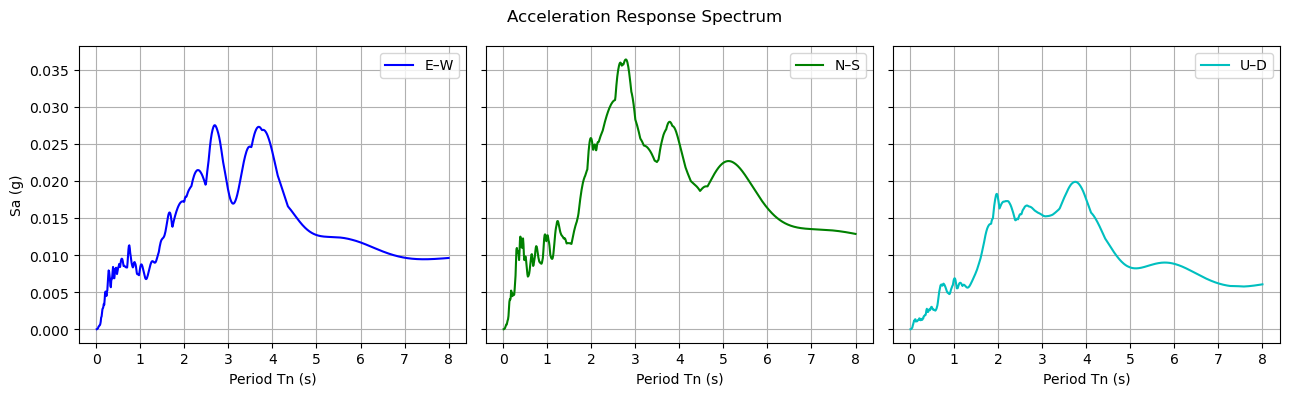

In [4]:
# Newmark-β Method (SDOF Response)
def sdof_newmark(acc, dt, Tn):
    """ Computes displacement, velocity, and acceleration response of an SDOF system using the Newmark-β method. """
    
    # SDOF parameters
    xi = 0.05                       # Damping ratio: 5%
    m = 1.0                         # Mass [Unit mass (standard practice)]
    u0 = 0.0 ; v0 = 0.0 ; a0 = 0.0  # Initial disp, vel, and acc, respectively
    method = "A"                    # A: Average acceleration, L: Linear acceleration

    # System properties
    omega_n = 2 * np.pi / Tn
    k = m * omega_n**2
    c = 2 * m * xi * omega_n

    # Newmark parameters
    gamma = 0.5
    beta = 1/6 if method.lower() == "l" else 1/4

    # Effective force
    P = -m * acc

    # Newmark constants
    a1 = m / (beta * dt**2) + gamma * c / (beta * dt)
    a2 = m / (beta * dt) + (gamma / beta - 1) * c
    a3 = (1 / (2 * beta) - 1) * m + dt * (gamma / (2 * beta) - 1) * c
    k_eff = k + a1

    # Initialization
    u = [u0] ; v = [v0] ; a = [a0]

    # Time stepping
    for i in range(len(P) - 1):
        P_eff = P[i] + a1 * u[i] + a2 * v[i] + a3 * a[i]

        u_new = P_eff / k_eff
        v_new = (gamma / (beta * dt)) * (u_new - u[i]) \
                + (1 - gamma/beta) * v[i] \
                + dt * (1 - gamma / (2 * beta)) * a[i]
        a_new = (1 / (beta * dt**2)) * (u_new - u[i]) \
                - (1 / (beta * dt)) * v[i] \
                - (1 / (2 * beta) - 1) * a[i]

        u.append(u_new) ; v.append(v_new) ; a.append(a_new)

    return np.array(u), np.array(v), np.array(a)


# Response Spectrum Calculation
def response_spectrum_newmark(acc, dt, Tn):
    """ Computes Sd, Sv, and Sa response spectra using the Newmark method. """

    Sd, Sv, Sa = [], [], []
    for Ti in Tn:
        u, v, a = sdof_newmark(acc, dt, Ti)
        Sd.append(np.max(np.abs(u)))
        Sv.append(np.max(np.abs(v)))
        Sa.append(np.max(np.abs(a)))

    return np.array(Sd), np.array(Sv), np.array(Sa)


# Response Spectrum Calculation
# Spectrum periods
Tmax = 8.0     # [sec], maximum period
dT = 0.01      # [sec], period interval
Tn = np.arange(dT, Tmax + dT, dT)  # Period axis
Sd_E, Sv_E, Sa_E = response_spectrum_newmark(acc_E, dt, Tn)  # E-W component
Sd_N, Sv_N, Sa_N = response_spectrum_newmark(acc_N, dt, Tn)  # N-S component
Sd_U, Sv_U, Sa_U = response_spectrum_newmark(acc_U, dt, Tn)  # U-D component

print("Response spectrum calculated.")


# Plot Response Spectra (side by side)
fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
fig.suptitle("Acceleration Response Spectrum", fontsize=12)
ax[0].plot(Tn, Sd_E, 'b', label="E–W")
ax[0].set_xlabel("Period Tn (s)")
ax[0].set_ylabel("Sa (g)")
# ax[0].set_title("Acceleration Response Spectrum")
ax[0].legend()
ax[0].grid()
ax[1].plot(Tn, Sd_N, 'g', label="N–S")
ax[1].set_xlabel("Period Tn (s)")
ax[1].legend()
ax[1].grid()
ax[2].plot(Tn, Sd_U, 'c', label="U–D")
ax[2].set_xlabel("Period Tn (s)")
ax[2].legend()
ax[2].grid()
plt.tight_layout()
plt.show()

### 3. Horizontal Acceleration Elastic Design Spectrum 
According to the Turkish Earthquake Code for Buildings 2018 (TECB-2018)

![](./Figures/DesignSpectrum/Ex_Design_SpectrumHor2.png)
![](./Figures/DesignSpectrum/Ex_Design_SpectrumHor1.png)

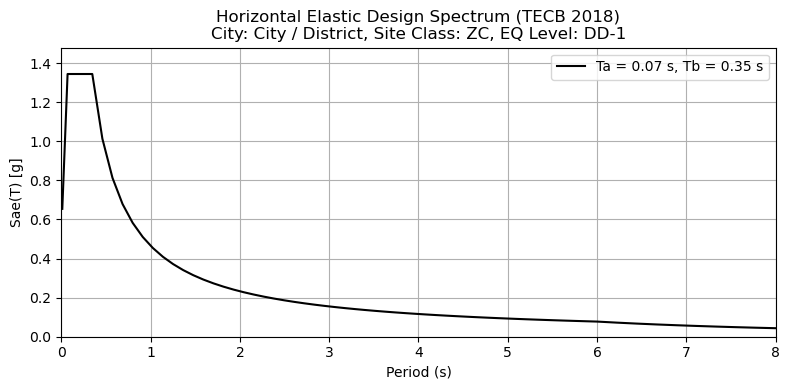

In [5]:
def horizontal_design_spectrum_TECB2018(Ss, Fs, S1, F1):
    """
    Computes the Horizontal Elastic Design Spectrum according to TECB-2018.

    Returns:
      T : Period values (s)
      Sae : Elastic spectral accelerations (in units of g)
      Ta : Corner period Ta (s)
      Tb :  Corner period Tb (s)
    """

    # Design spectral acceleration coefficients
    Sds = Ss * Fs
    Sd1 = S1 * F1

    # Corner periods (TBDY 2019)
    Ta = 0.2 * Sd1 / Sds
    Tb = Sd1 / Sds
    Tl = 6.0  # Long-period transition (s)

    # Period range definition
    T0 = 0.01   # Small non-zero value to avoid singularity at T = 0
    Tmax = 8.0   # Maximum period (s)

    T_part1 = np.linspace(T0, Ta, num=7, endpoint=False)     # 0 < T < Ta
    T_part2 = np.linspace(Ta, Tb, num=5, endpoint=False)     # Ta ≤ T < Tb
    T_part3 = np.linspace(Tb, Tl, num=50, endpoint=False)    # Tb ≤ T < Tl
    T_part4 = np.linspace(Tl, Tmax, num=10, endpoint=True)   # Tl ≤ T ≤ Tmax

    T = np.concatenate([T_part1, T_part2, T_part3, T_part4])

    # Elastic spectral acceleration (Sae)
    Sae = np.zeros_like(T)

    for i, Ti in enumerate(T):
        if Ti < Ta:
            Sae[i] = (0.4 + 0.6 * Ti / Ta) * Sds
        elif Ta <= Ti < Tb:
            Sae[i] = Sds
        elif Tb <= Ti <= Tl:
            Sae[i] = Sd1 / Ti
        else:
            Sae[i] = Sd1 * Tl / Ti**2

    return T, Sae, Ta, Tb


# Input Parameters
# Location and site information
city       = "City / District"   # Location
site_class = "ZC"                # soil class
EQ_Level   = "DD-1"              # Earthquake level

# Seismic hazard parameters 
Ss = 1.120   # Short-period spectral acceleration coefficient
S1 = 0.310   # 1.0-second spectral acceleration coefficient
Fs = 1.200   # Short-period site coefficient
F1 = 1.500   # 1.0-second site coefficient

# Spectrum Calculation
T, Sae, Ta, Tb = horizontal_design_spectrum_TECB2018(Ss, Fs, S1, F1)

# Unit conversion
scale_factor = 1.0            # Unit conversion factor; 1.0 for [g], 9.81 for [m/s²]
Sae = Sae * scale_factor


# Plot Horizontal Elastic Design Spectrum
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(T, Sae, color="k", linewidth=1.5)
ax.set_xlabel("Period (s)")
ax.set_ylabel("Sae(T) [g]")
ax.set_title(
    "Horizontal Elastic Design Spectrum (TECB 2018)\n"
    f"City: {city}, Site Class: {site_class}, EQ Level: {EQ_Level}")
ax.set_xlim(0, T[-1])
ax.set_ylim(0, 1.1 * Sae.max())
ax.legend([f"Ta = {Ta:.2f} s, Tb = {Tb:.2f} s"])
ax.grid(True)
plt.tight_layout()
plt.show()

### 4. Comparison of Response Spectrum with Horizontal Elastic Design Spectrum (TECB-2018)

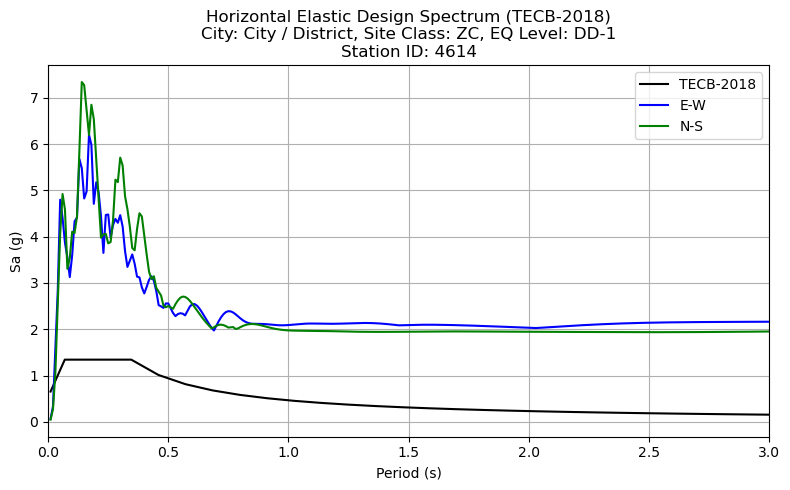

In [6]:
# Plot Horizontal Elastic Design Spectrum and calculated horizontal spectral accelerations
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(T, Sae, color="k", linewidth=1.5, label="TECB-2018")
ax.plot(Tn, Sa_E, color="b", linewidth=1.5, label="E-W")
ax.plot(Tn, Sa_N, color="g", linewidth=1.5, label="N-S")
ax.set_xlabel("Period (s)")
ax.set_ylabel("Sa (g)")
ax.set_title(
    "Horizontal Elastic Design Spectrum (TECB-2018)\n"
    f"City: {city}, Site Class: {site_class}, EQ Level: {EQ_Level}\n"
    f"Station ID: {st_id}" )

# ax.set_xlim(0, T[-1])
ax.set_xlim(0, 3)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()